In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
import imageio
import os
from scipy.stats import mode
import skimage as ski
import time as tt
from mpl_toolkits.mplot3d import Axes3D
import csv
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import math
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
from matplotlib.patches import Patch

In [145]:
# =============================================================================
# Functions for Agent Behavior
# =============================================================================

def AskN(i, I, T, c):
    """
    Ask function for NEED: Agent i chooses a product it needs if its inventory is <= 0.
    
    Parameters:
        i (int): Agent index.
        I (np.array): Inventory matrix.
        T (np.array): Memory matrix.
        c (str): Indicator variable (unused input here).
        
    Returns:
        prod_i_want (int): The product the agent wants (or -1 if none needed).
        c (str): Indicator ("N" for need, "H" otherwise).
    """
    need_i = np.where(I[i, :] <= 0)[0]
    if need_i.size > 0:
        prod_i_want = np.random.choice(need_i)
        c = "N"
    else:
        prod_i_want = -1
        c = "H"
    return prod_i_want, c


def AskG(i, I, T, c):
    """
    Ask function for GREED: Agent i chooses a product based on its memory or randomly.
    
    Parameters:
        i (int): Agent index.
        I (np.array): Inventory matrix.
        T (np.array): Memory matrix.
        c (str): Indicator variable (unused input here).
        
    Returns:
        prod_i_want (int): The product chosen.
        c (str): Always "G" for greed.
    """
    if len(T[i][T[i] != -1]) == 0:
        prod_i_want = np.random.randint(0, L)
    else:
        prod_i_want = np.random.choice(T[i][T[i] != -1])
    c = "G"
    return prod_i_want, c


def Ask(Start_cond, I, T):
    """
    Combined Ask function: Agent i prioritizes need (inventory zero) over greed.
    
    Parameters:
        Start_cond : tuple (t_max, N, L, U, M, sigma, w)   # no fixed M any more
        I          : (N×L) np.ndarray of inventories
        T          : list of length N, T[i] is np.ndarray of length M_i[i]
    
    Returns:
        prod_i_want : (N,) np.ndarray of chosen product‐indices
        c           : (N,) np.ndarray of "G" or "N"
    """
    # unpack (we ignore M since memory is ragged)
    t_max, N, L, U, M, sigma, w = Start_cond

    # need_mask[i]==True if agent i has at least one zero in its inventory
    need_mask  = np.any(I == 0, axis=1)
    greed_mask = ~need_mask

    # --- greed choices: pick one random slot from each T[i]
    # for each i, draw idx in [0, len(T[i]))
    random_indices = [np.random.randint(len(mem_i)) for mem_i in T]
    T_choices = np.array([ T[i][random_indices[i]] for i in range(N) ])
    
    # --- need choices: pick uniformly among the zero‐inventory good(s)
    I_choices = -np.ones(N, dtype=int)
    for i in range(N):
        zeros = np.where(I[i] == 0)[0]
        if zeros.size > 0:
            I_choices[i] = np.random.choice(zeros)

    # --- assemble final
    prod_i_want = np.where(greed_mask, T_choices, I_choices)
    c           = np.where(greed_mask, "G", "N")

    return prod_i_want, c

# =============================================================================
# Functions for Trade and Memory Updates
# =============================================================================

def Trade(Start_cond, N_ij, N_ij_want, I, T, frac, trade, Agents_score, demand):
    """
    Performs a trade between agents i and j exchanging products.
    """
    t_max, N, L, U, M, sigma, w = Start_cond
    half = N // 2
    N_ij_want = np.array(N_ij_want, dtype=np.int64)
    frac_A = frac[:half]
    frac_B = frac[half:]
    # Split into two halves:
    A = N_ij[:half]
    B = N_ij[half:]
    
    # Determine the columns corresponding to the 'wants'
    cols_A = N_ij_want[A]
    cols_B = N_ij_want[B]
    
    # Build the condition vector:
    # Trade is allowed only if for each pair, both:
    #   I[b, N_ij_want[a]] != 0  and  I[a, N_ij_want[b]] != 0.
    cond = (I[B, cols_A] != 0) & (I[A, cols_B] != 0)

    # Log the failed trades
    failed_trade = np.concatenate((cols_A[~cond],cols_B[~cond]))
    histogram_failed_trade = np.bincount(failed_trade, minlength=L)
    
    # Now extract only the pairs where condition is met:
    A_valid = A[cond]
    B_valid = B[cond]
    cols_A_valid = N_ij_want[A_valid]
    cols_B_valid = N_ij_want[B_valid]
    
    # Apply the trade updates:
    I[A_valid, cols_A_valid] += 1
    I[B_valid, cols_A_valid] -= 1
    I[A_valid, cols_B_valid] -= 1
    I[B_valid, cols_B_valid] += 1
    frac_A_valid = frac_A[cond]
    frac_B_valid = frac_B[cond]
        
    # Update agent scores based on previous demand (note: uses trade-1 index)
    Agents_score[trade, A_valid] = demand[trade - 1, cols_A_valid] - demand[trade - 1, cols_B_valid]
    Agents_score[trade, B_valid] = demand[trade - 1, cols_B_valid] - demand[trade - 1, cols_A_valid]
    
    # If desired, combine the valid frac parts:
    frac_valid = np.concatenate([frac_A_valid, frac_B_valid])
    return frac_valid, histogram_failed_trade


def MemoryUpdate(Start_cond, N_ij, N_ij_want, I, T, M_i):
    """
    - Start_cond: (t_max, N, L, U, sigma, w)  # no fixed M
    - N_ij      : array of length N, pairing agents for this round
    - N_ij_want : array of length N, each agent’s “wanted” item‐type
    - I         : any other state you carry (unused here)
    - T         : list of length N; T[i] is an array of length M_i[i]
    - M_i       : array of each agent’s memory length
    """
    t_max, N, L, U, M, sigma, w = Start_cond

    # pick one random slot *within each agent’s own memory*
    # memory_index[i] in [0, M_i[i])
    memory_index = np.array([np.random.randint(mi) for mi in M_i])

    half = N // 2
    A = N_ij[:half]
    B = N_ij[half:]

    wants_A = N_ij_want[A]
    wants_B = N_ij_want[B]

    # for each matched pair, overwrite one random slot
    for idx, a in enumerate(A):
        T[a][ memory_index[a] ] = wants_B[idx]
    for idx, b in enumerate(B):
        T[b][ memory_index[b] ] = wants_A[idx]

    return T

def Pro_Consumption(Start_cond, N_ij, I, T):
    """
    Handle production (+1) and consumption (–1) for each agent i
    with probability sigma, using ragged memory T.

    Parameters
    ----------
    Start_cond : tuple
        (t_max, N, L, U, M, sigma, w)
          - sigma : prob. of “act” per agent
    N_ij       : array-like of length N  # unused here, but kept for signature
    I          : (N×L) inventory array, modified in-place
    T          : list of length N, where T[i] is 1D np.array of length M_i[i]

    Returns
    -------
    None   # I is updated in-place
    """
    # unpack (no fixed M any more)
    t_max, N, L, U, M, sigma, w = Start_cond

    # 1) decide which agents act
    rand_vals = np.random.rand(N)
    mask      = rand_vals <= sigma
    actors    = np.where(mask)[0]   # indices of agents who will produce & consume

    # 2) PRODUCTION: each acting agent i produces item T[i][random_slot]
    for i in actors:
        mem_i = T[i]
        slot  = np.random.randint(len(mem_i))
        prod  = mem_i[slot]
        I[i, prod] += 1

    # 3) CONSUMPTION: each acting agent i consumes one unit uniformly
    #    among whatever they currently have >0
    for i in actors:
        positive = np.nonzero(I[i] > 0)[0]
        if positive.size:
            # pick one at random by drawing a random for each and taking the min:
            rands = np.random.rand(positive.size)
            choice = positive[np.argmin(rands)]
            I[i, choice] -= 1
        # else: nothing to consume

    # no need to return I, since it's in-place


# =============================================================================
# Functions for Selecting Agents and News
# =============================================================================

def pick_agents1D(Amount, cons, Agent_grid):
    """
    Picks two distinct agents randomly (1D).
    """
    return np.random.choice(N, 2, replace=False)


def pick_agents2D(Amount, cons, Agent_grid):
    """
    Picks two distinct agents from a 2D grid with periodic boundaries.
    """
    x, y = np.random.randint(0, w, 2)
    i = Agent_grid[x, y]
    
    while True:
        dx, dy = np.random.choice(range(-cons, cons + 1), 2)
        x2 = (x + dx) % w
        y2 = (y + dy) % w
        j = Agent_grid[x2, y2]
        if i != j:
            return i, j


def weighted_random(M):
    """
    Returns a weighted random integer based on an exponential decay.
    Adjust the decay parameter (L/9) as needed.
    """
    weights = np.exp(-np.arange(1, L + 1) / (L / 9))
    weights /= weights.sum()
    return np.random.choice(np.arange(1, L + 1), p=weights)


def news1D(Amount, sigma, L, Agent_grid, I, T):
    """
    Placeholder for news effect in 1D.
    """
    x = Amount  # Currently does nothing


def news2D(Amount, sigma, L, Agent_grid, I, T):
    """
    Updates the memory of agents in a 2D grid based on weighted news.
    """
    if np.sqrt(np.random.randn() ** 2) <= sigma:
        prod_news = np.random.randint(0, L)
        news_weight = weighted_random(M)

        # Select a random coordinate within the grid
        x1, y1 = np.random.randint(0, round(np.sqrt(Amount)), 2)
        # Define neighbor coordinates with wrapping
        x0, y0 = ((x1 - 1) % w, (y1 - 1) % w)
        x2, y2 = ((x1 + 1) % w, (y1 + 1) % w)
        
        # Collect agents in a 3x3 neighborhood
        a0 = Agent_grid[x0, y0]
        b0 = Agent_grid[x0, y1]
        c0 = Agent_grid[x0, y2]
        a1 = Agent_grid[x1, y0]
        b1 = Agent_grid[x1, y1]
        c1 = Agent_grid[x1, y2]
        a2 = Agent_grid[x2, y0]
        b2 = Agent_grid[x2, y1]
        c2 = Agent_grid[x2, y2]
        neighborhood = [a0, b0, c0, a1, b1, c1, a2, b2, c2]

        for ag in neighborhood:
            for _ in range(news_weight):
                memory_index = np.random.randint(0, M)
                T[ag, memory_index] = prod_news


# =============================================================================
# Utility Functions
# =============================================================================

def random_min_index(lst):
    """
    Chooses a random index among the indices corresponding to the minimum value in a list.
    """
    min_value = min(lst)
    min_indices = [i for i, val in enumerate(lst) if val == min_value]
    return random.choice(min_indices)


def most_prominent(arr):
    """
    Counts the most prominent (frequent) element in each row of arr, ignoring -1.
    Returns a numpy array of the most frequent elements per row.
    """
    result = []
    for row in arr:
        filtered_row = [x for x in row if x != -1]
        if not filtered_row:
            result.append(0)
        else:
            counter = Counter(filtered_row)
            max_count = max(counter.values())
            # Get the first candidate with the maximum count
            candidates = [num for num in filtered_row if counter[num] == max_count]
            result.append(candidates[0])
    return np.array(result)


def Hurst(L_list, T_window):
    """
    Computes an estimate for the Hurst exponent based on a given time window.
    
    Parameters:
        L_list (list or np.array): A list of values.
        T_window (int): The window size for calculation.
        
    Returns:
        float: The mean squared difference over the window.
    """
    Temp = []
    for i, k in enumerate(L_list[:-T_window]):
        c = (np.log(L_list[i + T_window]) - np.log(L_list[i])) ** 2
        Temp.append(c)
    return np.sqrt(np.nanmean(Temp))



def count_elements_in_chunks(data, t_max, L):
    """
    Counts occurrences of each product in chunks of the timeline.
    
    Parameters:
        data (np.array): 1D array with trade data.
        t_max (int): Total number of iterations.
        L (int): Number of products.
        
    Returns:
        np.array: A 2D array with counts per chunk and a time indicator.
    """
    num_chunks = t_max // 50
    counts = np.full((num_chunks, L + 1), np.nan, dtype=float)
    
    for i in range(num_chunks):
        chunk = data[i * 100 : (i + 1) * 100]
        for p in range(L):
            counts[i, p] = (chunk == p).sum()
        counts[i, p + 1] = i * 50
    return counts


def Talk(i, j, I, T):
    """
    Allows agents i and j to discuss a product.
    If both discuss the same product, update their memory.
    """
    if len(T[i][T[i] != -1]) == 0:
        prod_i_talk = np.random.randint(0, L)
    else:
        prod_i_talk = np.random.choice(T[i][T[i] != -1])
    
    if len(T[j][T[j] != -1]) == 0:
        prod_j_talk = np.random.randint(0, L)
    else:
        prod_j_talk = np.random.choice(T[j][T[j] != -1])
    
    if prod_i_talk == prod_j_talk:
        MemoryUpdate(i, j, prod_i_talk, prod_j_talk, I, T)

def init_memory(N, L, M_i, shuffle=True):
    """
    N    : number of agents
    L    : number of distinct item‐types
    M_i  : 1D array (length N) giving each agent’s memory size
    """
    # total number of memory slots
    S = int(np.sum(M_i))
    # how many full repeats per item-type
    base = S // L
    values = np.tile(np.arange(L), base)

    # handle any leftover slots by sampling at random
    leftover = S - values.size
    if leftover > 0:
        # if leftover <= L, sample without replacement; else with replacement
        replace = leftover > L
        extra = np.random.choice(np.arange(L), size=leftover, replace=replace)
        values = np.concatenate([values, extra])

    if shuffle:
        np.random.shuffle(values)

    # now slice out each agent’s block of length M_i[i]
    T = []
    offset = 0
    for m in M_i:
        block = values[offset : offset + m]
        T.append(block.copy())      # ensure each is independent
        offset += m

    return T

In [283]:
# =============================================================================
# Main Simulation Function
# =============================================================================

def Trade_Sim(Start_cond):
    """
    Main simulation function for trade among agents.
    
    Parameters:
        Start_cond (tuple): (t_max, N, L, U, M,) The important starting conditions .
        D (int): Dimension flag (2 for 2D, else 1D).
        Type (int): Trade type indicator:
                    2 -> Only Greed,
                    3 -> Only Need,
                    Other -> Normal (both).
                    
    Returns:
        tuple: (I_history, T_history, Frac, Trade_history, Demand_list, Agents_score)
    """
    t_max, N, L, U, M, sigma, w = Start_cond

    # Initialize inventory for each agent

    I = np.zeros((N,L))

    # Create a shuffled array of products to distribute equally among agents
    '''
    products = np.tile(np.arange(L), N // L)
    products = np.tile(products, U)
    '''
    
    products = np.tile(np.arange(L), U // L)
    products = np.tile(products, N)
   
    
    np.random.shuffle(products)
    indexN = 0
    for idx, prod in enumerate(products):
        if idx % U == 0 and idx != 0:
            indexN += 1
        agent = indexN
        # if agent is in the last ten, give them 2 units per assignment
        I[agent, prod] += 1 
    '''


    U_agents = 20 + np.arange(N, dtype=int)*10   

    for agent, u in enumerate(U_agents):
        # build a little pool of products for this agent
        # first tile full cycles of 0….L-1
        cycles = u // L
        prods  = np.tile(np.arange(L), cycles)
        # if there's a remainder, pick that many at random
        rem = u % L
        if rem:
            prods = np.concatenate([prods,
                                    np.random.choice(np.arange(L), size=rem, replace=False)])
        # shuffle and assign
        np.random.shuffle(prods)
        for p in prods:
            I[agent, p] += 1
    '''
   # M_i = np.arange(0,3*M, 3*M//N, dtype=int)+M
    M_i = np.ones(N, dtype=int)*M
    M_i[25:] = M*4
    T = init_memory(N, L, M_i, shuffle=True)


    # Prepare histories and tracking arrays
    I_history = np.empty((t_max, N, L), dtype=int)
    T_history = [None] * t_max
    Demand_list = np.empty((t_max, L))
    Trade_history = -np.ones(t_max * 2, dtype=int)
    Agents_score = np.zeros((t_max, N))
    Failed_trades = np.ones((t_max,L))
    Trade_index = 0 # Pointer for filling Trade_history

    # Fraction counters: each row is [time_chunk, fraction_greed, fraction_need]
    Frac = np.empty((t_max, 3))

    Asking = Ask

    # Main simulation loop
    for trade in range(t_max):
        N_ij = np.arange(N)       # array of 0 to N-1
        np.random.shuffle(N_ij)   # Agent pairs, Agent 0 trades with 50

        
        # Optionally include discussion (currently commented out)
        # if np.sqrt(np.random.randn()**2) <= sigma and sigma != 0:
        #     Talk(i, j, I, T)
        
        # Production/Consumption step for both agents
        #Pro_Consumption(Start_cond, N_ij, I, T)
        # Optionally, news can be incorporated:
        # news(N, sigma / 100, L, Agent_grid, I, T)
        
        # Agents decide what product they want based on their strategy
        N_ij_want, c = Asking(Start_cond, I, T)
        
        frac = (c == "G")
        
        # Process the trade if both agents have valid choices and available inventory
        cnew, hft = Trade(Start_cond, N_ij,N_ij_want, I, T, frac, trade, Agents_score, Demand_list)

        Failed_trades[trade] = hft
        Frac[trade] = trade, np.nanmean(cnew), 1 - np.nanmean(cnew)

        # 1) make a 1D array of all memory entries
        flat_memory = np.concatenate(T)  
        
        # 2) count occurrences of each product in 0..L-1
        counts = np.bincount(flat_memory, minlength=L)
        
        # 3) compute total slots
        total_slots = flat_memory.size   # same as sum(len(mem_i) for mem_i in T)
        
        # 4) record the demand fraction
        Demand_list[trade, :] = counts / total_slots

        # Cumulative agent score update
        Agents_score[trade, :] += Agents_score[trade - 1, :]
        
        # Update agents' memories based on the trade (or attempted trade)
        MemoryUpdate(Start_cond, N_ij, N_ij_want, I, T, M_i)

        # Save current state of inventory and memory
        I_history[trade] = I.copy()
        T_history[trade] = [ mem.copy() for mem in T ]

    return I_history, T_history, Frac, Demand_list, Agents_score, Failed_trades

In [284]:
U_list = [50, 125, 500, 1250, 2500]

[125 125 125 125 125 125 125 125 125 125 125 125 125 125 125 125 125 125
 125 125 125 125 125 125 125 500 500 500 500 500 500 500 500 500 500 500
 500 500 500 500 500 500 500 500 500 500 500 500 500 500]


In [296]:
Demand15 = np.zeros((10,20000,25))
Score15 = np.zeros((10,20000,50))
for i in range(10):
    Default_cond = (20000, 50, 25, 50, 125, 0, 10)
    t_max, N, L, U, M, sigma, w = Default_cond
    start = tt.perf_counter()
    I_history, T_history, Frac, Demand_list, Agents_score, Failed_trades = Trade_Sim(Default_cond)
    time = tt.perf_counter() - start
    print(f"Done, simulation took {time}")
    Demand15[i] = Demand_list
    Score15[i] = Agents_score

Done, simulation took 24.33370080000168
Done, simulation took 26.782198500004597
Done, simulation took 27.713378200001898
Done, simulation took 26.85721740000008
Done, simulation took 25.39947179999581
Done, simulation took 27.179468300004373
Done, simulation took 27.02988329999789
Done, simulation took 27.112329099996714
Done, simulation took 25.463187099994684
Done, simulation took 28.52735450000182


In [276]:
print(T_history[0])

[array([ 5, 21, 12, 11, 22,  7, 24, 17, 15, 15,  8, 16, 11,  9,  5,  3, 20,
       18,  9,  4, 22, 14, 15, 18,  7,  8, 16,  7, 23,  4,  6, 21,  7, 24,
        1, 10,  8,  3,  0, 15, 13,  3,  6,  4, 18, 14, 24, 15, 22,  5, 15,
        1, 19,  3, 10,  9, 18,  8, 22,  2,  2,  9, 14, 17, 16,  9,  1, 13,
       21,  1, 15,  0,  8, 14, 11,  9, 13,  3,  0, 16, 24,  3, 22,  3, 17,
       24,  6, 15, 17, 14, 22, 21, 21, 19, 22,  7,  9,  4, 18, 16, 10, 12,
       17,  9, 13,  0, 22, 17,  9, 13,  4,  3,  4,  3, 14, 17, 15,  4,  9,
       16, 11, 12, 24,  0, 22]), array([ 6, 15, 19, 21,  2, 20, 22, 20,  5, 17, 15,  8, 15,  4, 23, 10, 19,
        5,  6, 13,  2,  7,  0,  9,  9, 15, 21, 10, 11, 18, 21,  1, 13, 13,
        1, 10,  2, 10,  9, 10,  2, 23,  6, 17,  5,  9,  5, 13, 23, 21, 23,
       15, 14,  2, 16,  5,  3,  9,  0, 11, 22, 21,  8, 22,  5,  4,  6, 24,
       19,  2, 20,  8, 22, 20, 15,  5,  4, 22, 13, 23,  6,  1, 15,  5, 10,
        8, 20, 15, 14, 13, 10, 10,  7, 23, 20,  2,  7,  4,  5,  7,

0.09025521743999924 -0.09025521744000005


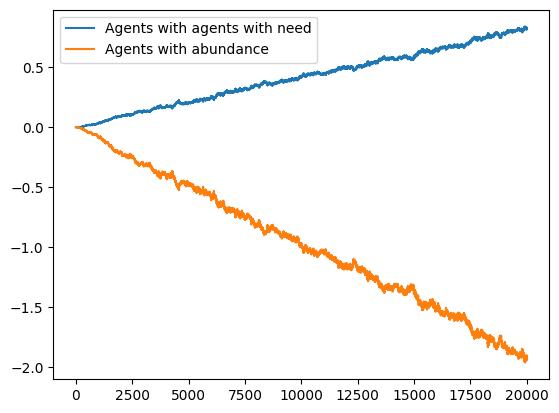

In [132]:
Agents_score = np.nanmean(Score1, axis=0)
Agent_low_U = np.mean(Agents_score[:,:70], axis=1)
Agent_high_U = np.mean(Agents_score[:,70:], axis=1)
print(np.mean(Agent_low_mem), np.mean(Agent_high_mem))
plt.plot(Agent_low_U, label="Agents with agents with need")
plt.plot(Agent_high_U, label="Agents with abundance")
plt.legend()
plt.show()

0.09025521743999924 -0.09025521744000005


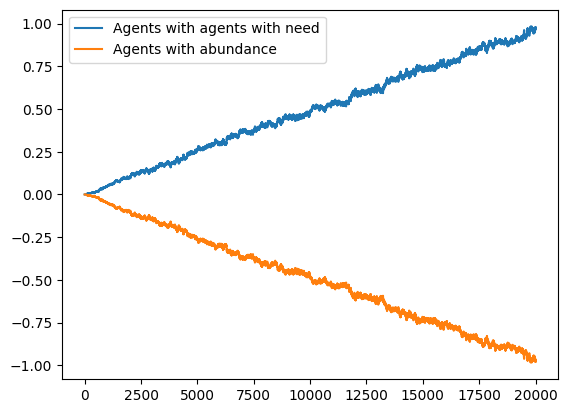

In [134]:
Agents_score = np.nanmean(Score2, axis=0)
Agent_low_U = np.mean(Agents_score[:,:50], axis=1)
Agent_high_U = np.mean(Agents_score[:,50:], axis=1)
print(np.mean(Agent_low_mem), np.mean(Agent_high_mem))
plt.plot(Agent_low_U, label="Agents with agents with need")
plt.plot(Agent_high_U, label="Agents with abundance")
plt.legend()
plt.show()

0.09025521743999924 -0.09025521744000005


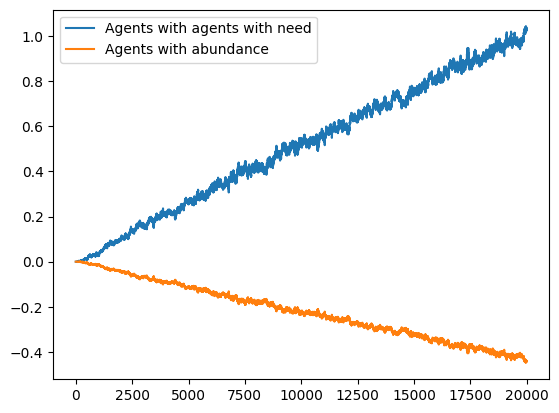

In [137]:
Agents_score = np.nanmean(Score3, axis=0)
Agent_low_U = np.mean(Agents_score[:,:30], axis=1)
Agent_high_U = np.mean(Agents_score[:,30:], axis=1)
print(np.mean(Agent_low_mem), np.mean(Agent_high_mem))
plt.plot(Agent_low_U, label="Agents with agents with need")
plt.plot(Agent_high_U, label="Agents with abundance")
plt.legend()
plt.show()

0.09025521743999924 -0.09025521744000005


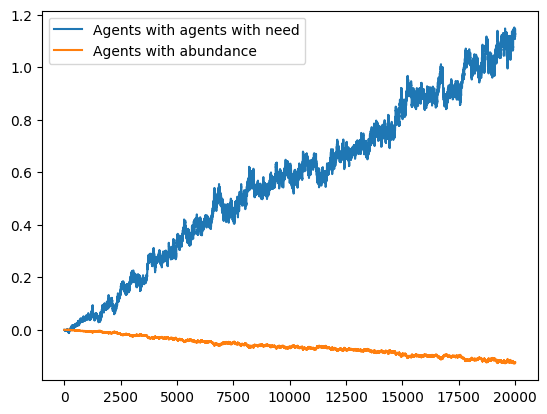

In [140]:
Agents_score = np.nanmean(Score4, axis=0)
Agent_low_U = np.mean(Agents_score[:,:10], axis=1)
Agent_high_U = np.mean(Agents_score[:,10:], axis=1)
print(np.mean(Agent_low_mem), np.mean(Agent_high_mem))
plt.plot(Agent_low_U, label="Agents with agents with need")
plt.plot(Agent_high_U, label="Agents with abundance")
plt.legend()
plt.show()

0.09025521743999924 -0.09025521744000005


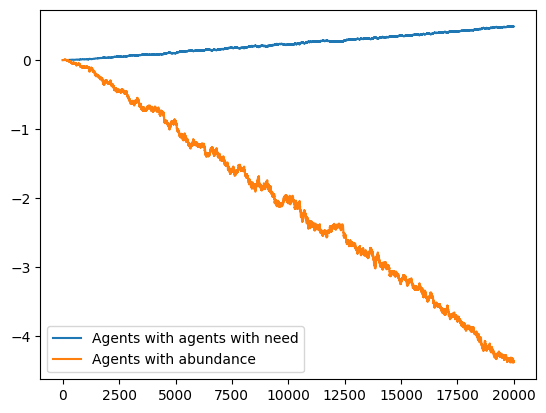

In [160]:
Agents_score = np.nanmean(Score5, axis=0)
Agent_low_U = np.mean(Agents_score[:,:90], axis=1)
Agent_high_U = np.mean(Agents_score[:,90:], axis=1)
print(np.mean(Agent_low_mem), np.mean(Agent_high_mem))
plt.plot(Agent_low_U, label="Agents with agents with need")
plt.plot(Agent_high_U, label="Agents with abundance")
plt.legend()
plt.show()

In [198]:
print(np.sum(I_history[5000,86,:]))

880


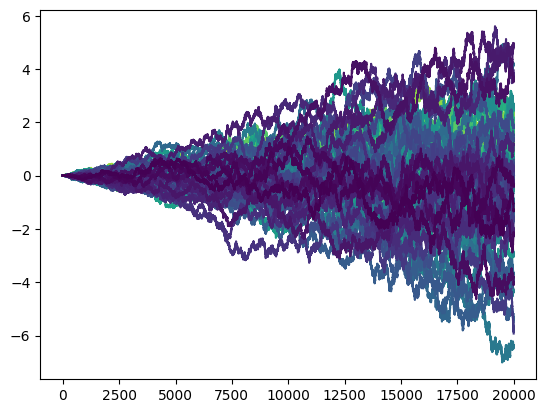

In [226]:
Agents_score = np.nanmean(Score6, axis=0)
#Agent_low_U = np.mean(Agents_score[:,:90], axis=1)
#Agent_high_U = np.mean(Agents_score[:,90:], axis=1)
amount = 90
colors = plt.cm.viridis(np.linspace(1, 0, amount))
for a in range(amount):
    plt.plot(Agents_score[:,a], color = colors[a])
plt.show()

0.09025521743999924 -0.09025521744000005


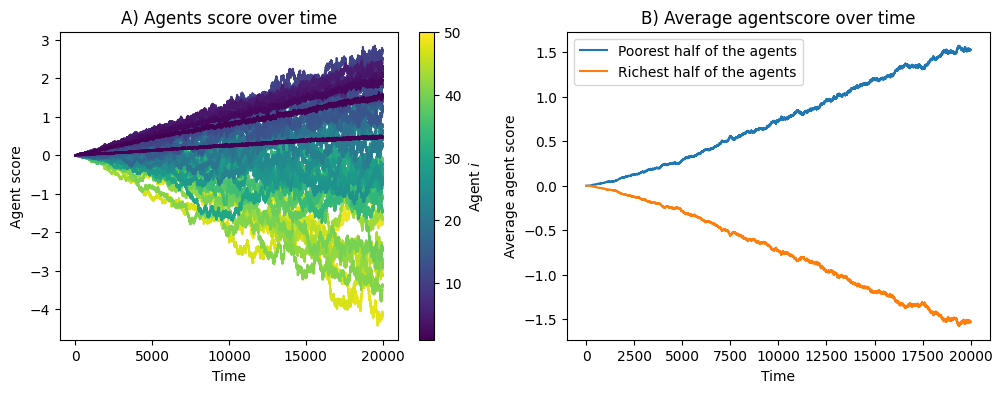

In [246]:
Agents_score = np.nanmean(Score7, axis=0)
amount = 50

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=1, vmax=amount)

# Plot
for a in range(amount):
    color = cmap(norm(49- a))
    plt.plot(Agents_score[:, 49 - a], color=color)

# Tell plt.colorbar which Axes to use
ax = plt.gca()
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array(np.arange(1, amount+1))   # or [] for newer mpl
cbar = plt.colorbar(sm, ax=ax)

cbar.set_label('Agent $i$')
plt.xlabel('Time')
plt.ylabel('Agent score')
plt.title('A) Agents score over time')

plt.subplot(1,2,2)
Agents_score = np.nanmean(Score7, axis=0)
Agent_low_U = np.mean(Agents_score[:,:25], axis=1)
Agent_high_U = np.mean(Agents_score[:,25:], axis=1)
print(np.mean(Agent_low_mem), np.mean(Agent_high_mem))
plt.plot(Agent_low_U, label="Poorest half of the agents")
plt.plot(Agent_high_U, label="Richest half of the agents")
plt.title("B) Average agentscore over time")
plt.xlabel('Time')
plt.ylabel('Average agent score')
plt.legend()
plt.show()

0.09025521743999924 -0.09025521744000005
0.09025521743999924 -0.09025521744000005
0.09025521743999924 -0.09025521744000005
0.09025521743999924 -0.09025521744000005


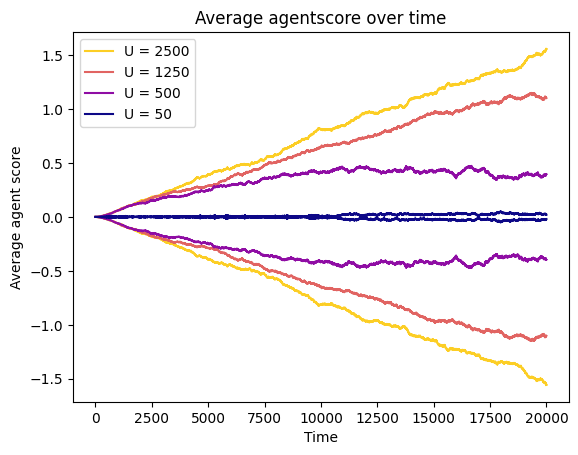

In [311]:
colors = plt.cm.plasma(np.linspace(0.9, 0, 4))

Agents_score = np.mean(Score11,axis=0)
Agent_low_U = np.mean(Agents_score[:,:25], axis=1)
Agent_high_U = np.mean(Agents_score[:,25:], axis=1)
print(np.mean(Agent_low_mem), np.mean(Agent_high_mem))
plt.plot(Agent_low_U, label="U = 2500", color = colors[0])
plt.plot(Agent_high_U, color = colors[0])

Agents_score = np.mean(Score12,axis=0)
Agent_low_U = np.mean(Agents_score[:,:25], axis=1)
Agent_high_U = np.mean(Agents_score[:,25:], axis=1)
print(np.mean(Agent_low_mem), np.mean(Agent_high_mem))
plt.plot(Agent_low_U, label="U = 1250", color = colors[1])
plt.plot(Agent_high_U, color = colors[1])
Agents_score = np.mean(Score13,axis=0)
Agent_low_U = np.mean(Agents_score[:,:25], axis=1)
Agent_high_U = np.mean(Agents_score[:,25:], axis=1)
print(np.mean(Agent_low_mem), np.mean(Agent_high_mem))
plt.plot(Agent_low_U, label="U = 500", color = colors[2])
plt.plot(Agent_high_U, color = colors[2])
Agents_score = np.mean(Score15,axis=0)
Agent_low_U = np.mean(Agents_score[:,:25], axis=1)
Agent_high_U = np.mean(Agents_score[:,25:], axis=1)
print(np.mean(Agent_low_mem), np.mean(Agent_high_mem))
plt.plot(Agent_low_U, label="U = 50", color = colors[3])
plt.plot(Agent_high_U, color = colors[3])
plt.legend()
plt.title("Average agentscore over time")
plt.xlabel("Time")
plt.ylabel("Average agent score")
plt.show()

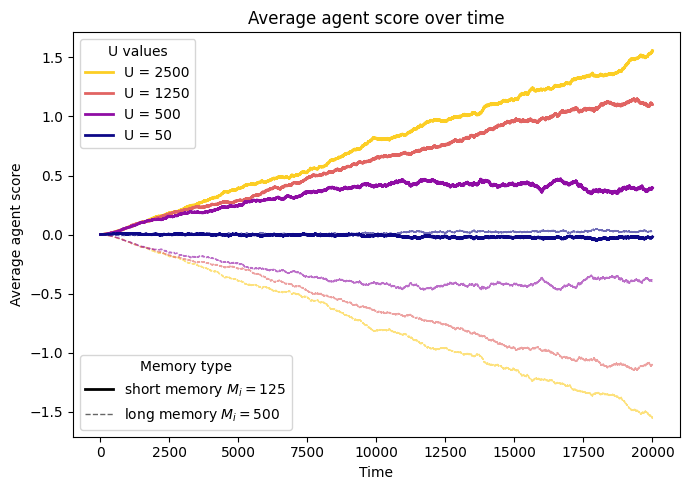

In [317]:
# replace these with your actual arrays
scores = [Score11, Score12, Score13, Score15]
U_labels = ["U = 2500", "U = 1250", "U = 500", "U = 50"]
colors = plt.cm.plasma(np.linspace(0.9, 0, len(scores)))

fig, ax = plt.subplots(figsize=(7, 5))

for score_array, label, color in zip(scores, U_labels, colors):
    Agents_score = np.mean(score_array, axis=0)
    low  = np.mean(Agents_score[:, :25], axis=1)   # short‐memory
    high = np.mean(Agents_score[:, 25:], axis=1)   # long‐memory

    # short-memory: solid, full alpha
    ax.plot(low,  label=label, color=color,
            linestyle='-', linewidth=2, alpha=1.0)
    # long-memory: dashed, lighter alpha + thinner
    ax.plot(high, color=color,
            linestyle='--', linewidth=1, alpha=0.6)

# first legend: U-values (by color)
leg1 = ax.legend(title="U values", loc='upper left')

# proxy artists for memory-type legend (match alpha & linestyle)
proxy_short = Line2D([0], [0], color='black',
                     linestyle='-', linewidth=2, alpha=1.0)
proxy_long  = Line2D([0], [0], color='black',
                     linestyle='--', linewidth=1, alpha=0.6)

leg2 = ax.legend(
    [proxy_short, proxy_long],
    [r"short memory $M_i = 125$", r"long memory $M_i = 500$"],
    title="Memory type",
    loc='lower left'
)

ax.add_artist(leg1)   # re-add the first legend

ax.set_title("Average agent score over time")
ax.set_xlabel("Time")
ax.set_ylabel("Average agent score")
plt.tight_layout()
plt.show()

0.09025521743999924 -0.09025521744000005


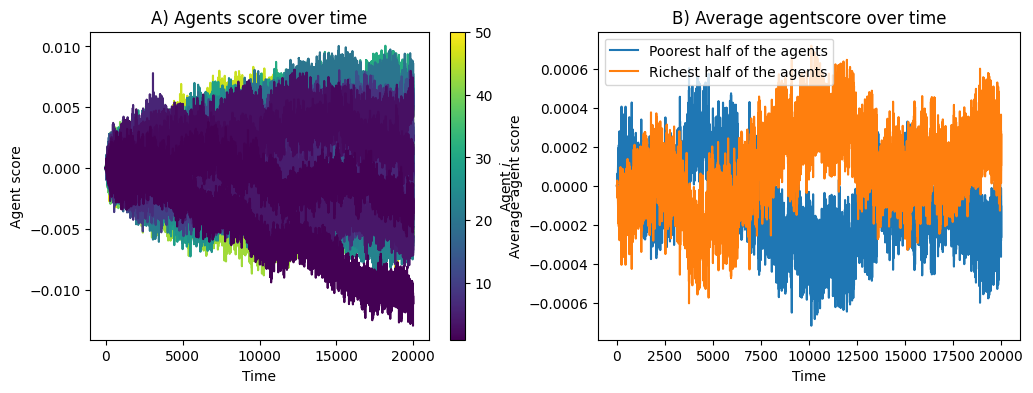

In [269]:
Agents_score = np.nanmean(Score10, axis=0)
amount = 50

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=1, vmax=amount)

# Plot
for a in range(amount):
    color = cmap(norm(49- a))
    plt.plot(Agents_score[:, 49 - a], color=color)

# Tell plt.colorbar which Axes to use
ax = plt.gca()
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array(np.arange(1, amount+1))   # or [] for newer mpl
cbar = plt.colorbar(sm, ax=ax)

cbar.set_label('Agent $i$')
plt.xlabel('Time')
plt.ylabel('Agent score')
plt.title('A) Agents score over time')

plt.subplot(1,2,2)
Agents_score = np.nanmean(Score10, axis=0)
Agent_low_U = np.mean(Agents_score[:,:25], axis=1)
Agent_high_U = np.mean(Agents_score[:,25:], axis=1)
print(np.mean(Agent_low_mem), np.mean(Agent_high_mem))
plt.plot(Agent_low_U, label="Poorest half of the agents")
plt.plot(Agent_high_U, label="Richest half of the agents")
plt.title("B) Average agentscore over time")
plt.xlabel('Time')
plt.ylabel('Average agent score')
plt.legend()
plt.show()

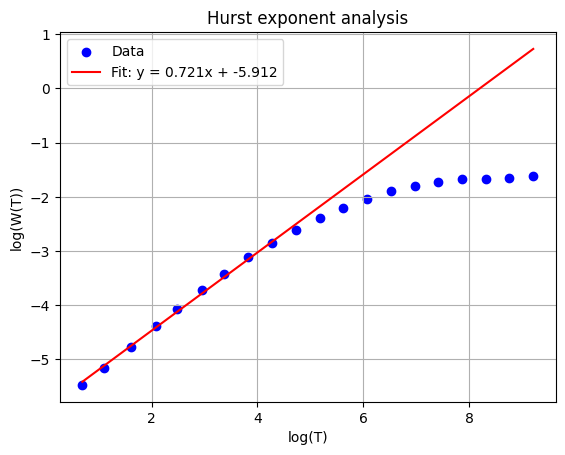

In [260]:

start = np.log(2)   # Avoid log(0); start from 1
end = np.log(10000)
TL = np.round( np.logspace(start, end, num=20, base = np.exp(1)),0).astype(int)
log_TL = np.log(TL)

W_list = np.zeros((25,20))
Fit_list = np.zeros((25,20))

for p in range(25):
    Temp2 = []
        
    for T in TL:
        Temp2.append(Hurst(Demand10[1,:,p], T))
    # Take the logarithm
    log_Temp2 = np.log(Temp2)
    slope, intercept = np.polyfit(log_TL[:10], log_Temp2[:10], 1)
    fitted_values = slope * log_TL + intercept
    W_list[p] = log_Temp2
    Fit_list[p] = fitted_values

W_list[W_list >= 100] = np.nan
W = np.nanmean(W_list, axis=0)
Fit = np.nanmean(Fit_list, axis = 0)
slope, intercept = np.polyfit(log_TL[:10], Fit[:10], 1)
plt.scatter(log_TL, np.nanmean(W_list, axis=0), label="Data", color='blue')
plt.plot(log_TL, np.nanmean(Fit_list, axis = 0), label=f"Fit: y = {slope:.3f}x + {intercept:.3f}", color='red')
plt.xlabel("log(T)")
plt.ylabel("log(W(T))")
plt.title("Hurst exponent analysis")
plt.legend()
plt.grid()
plt.show()